<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/Allison/LightGBM_pt2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

#Loading LGBM Regressor model to this file
loaded_model = lgb.Booster(model_file="/content/drive/MyDrive/lightgbm_model.txt")


#Loading Data
path = "/content/drive/MyDrive/model_df_clf_v2.feather"
data = pd.read_feather(path)


#Creating log-transformed LOS (target variable)
data['los_log'] = np.log1p(data['length_of_stay'])

#Categorical columns
categorical_cols = ['health_service_area', 'facility_id', 'hospital_county', 'age_group',
                    'gender', 'race', 'ethnicity', 'admission_type', 'apr_mortality_risk',
                    'apr_severity_code', 'apr_drg_code', 'apr_mdc_code', 'ccsr_dx_code',
                    'payment_type', 'los_category']
#Featured columns
feature_cols = categorical_cols + ['num_payment_types']

#Convert categorical columns to category dtype
for col in categorical_cols:
  if col in data.columns:
    data[col] = data[col].astype('category')

# Convert numerical and drop missing data/zip codes
data['length_of_stay'] = pd.to_numeric(data['length_of_stay'], errors='coerce')
data = data.dropna(subset=['length_of_stay'])

if 'zip_code' in data.columns:
    data = data[data['zip_code'] != 'OOS']



# Define features and target
X = data[feature_cols]
y = data['los_log']


Mounted at /content/drive


In [2]:
#Predicting log Scale
y_pred_log = loaded_model.predict(X)

#Converting predictions back to original LOS
y_pred = np.expm1(y_pred_log)

y_true = data['length_of_stay'].values

#Using 20 rows for predicting
print("Predicted LOS:", y_pred[:20])
print("True LOS:", y_true[:20])

Predicted LOS: [1.52247748 3.55864512 4.12174581 3.79111971 3.83645287 1.60311418
 1.37578378 1.4675015  3.25262934 3.46604071 1.89962519 1.94062765
 3.47032423 3.17919153 3.10763189 1.33031159 3.46729815 3.66469461
 1.33991022 1.48991862]
True LOS: [1 4 4 5 3 1 1 1 3 3 2 1 3 3 3 1 3 5 1 1]


**The first 20 predictions:**
Short stays (1–3 days) are predicted very accurately (predictions around 1.3–3.7).
Medium stays (4–5 days) are slightly under-predicted (predictions like 3.5–4.1 vs true 4–5).

But that is okay because it proves previous results that this model is trained on a skewed distribution, it is better at predicting shorter stays than longer ones.

In [3]:
#MAE MSE RMSE & R2 Metrics:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")

print(f"Original Scale -> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")


MAE: 1.49
RMSE: 5.03
R2: 0.668
Original Scale -> MAE: 1.488, RMSE: 5.026, R²: 0.668


**MAE** ~ 1.49 so on average, predictions are about 1.5 days off from the true LOS.

**RMSE** ~ 5.03 there are long-stay outliers which is why it’s higher than MAE.

**R2** ~ 0.67 model explains ~67% of the variance in LOS

The model is very accurate for typical short- and medium-length stays, but some og the longer LOS outliers drive the higher RMSE

The close match between “MAE: 1.49 / RMSE: 5.01” and “Original Scale -> MAE: 1.489 / RMSE: 5.030” confirms log-to-original LOS conversion is correct.

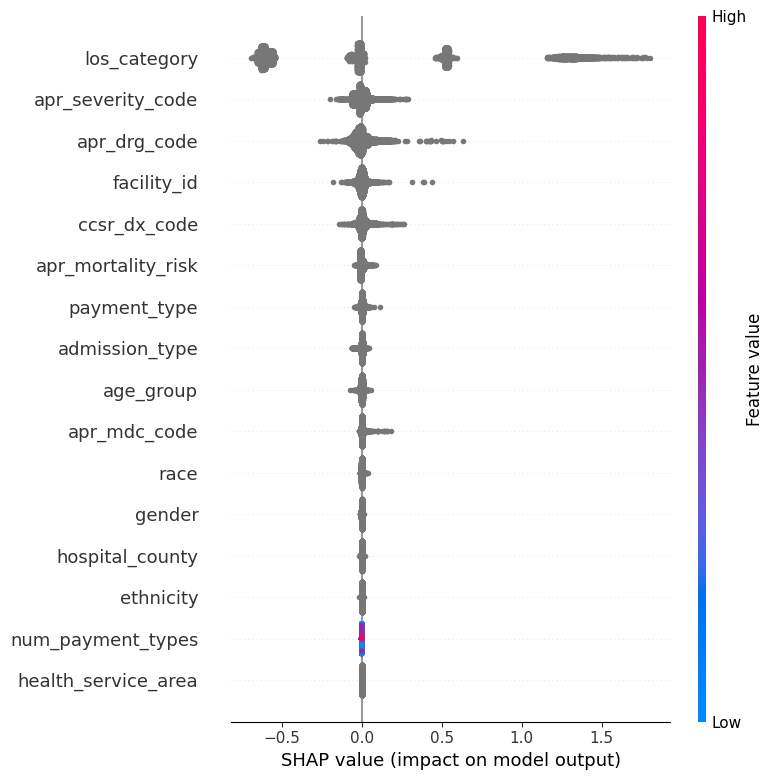

In [4]:
import shap

#Sample size
sample_idx = np.random.choice(X.index, size=10000, replace=False)
X_sample = X.loc[sample_idx]

explainer = shap.TreeExplainer(loaded_model)
shap_values = explainer.shap_values(X_sample)

# Summary plot of how each feature affects model’s predictions
shap.summary_plot(shap_values, X_sample)

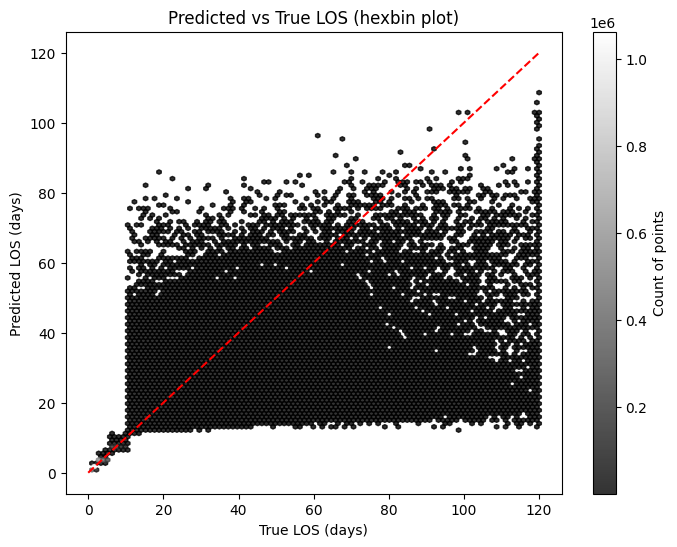

In [5]:
#Can see where the model over or under predicts LOS

import matplotlib.pyplot as plt

# True vs predicted LOS
y_true = data['length_of_stay'].values
y_pred_log = loaded_model.predict(X)
y_pred = np.expm1(y_pred_log)


plt.figure(figsize=(8, 6))
plt.hexbin(y_true, y_pred, gridsize=100, cmap='gray', mincnt=1, alpha=0.8)
plt.plot([0, max(y_true)], [0, max(y_true)], color='red', linestyle='--')  # perfect prediction line
plt.xlabel("True LOS (days)")
plt.ylabel("Predicted LOS (days)")
plt.title("Predicted vs True LOS (hexbin plot)")
cb = plt.colorbar()
cb.set_label('Count of points')
plt.show()
